# TITANIC DATASET

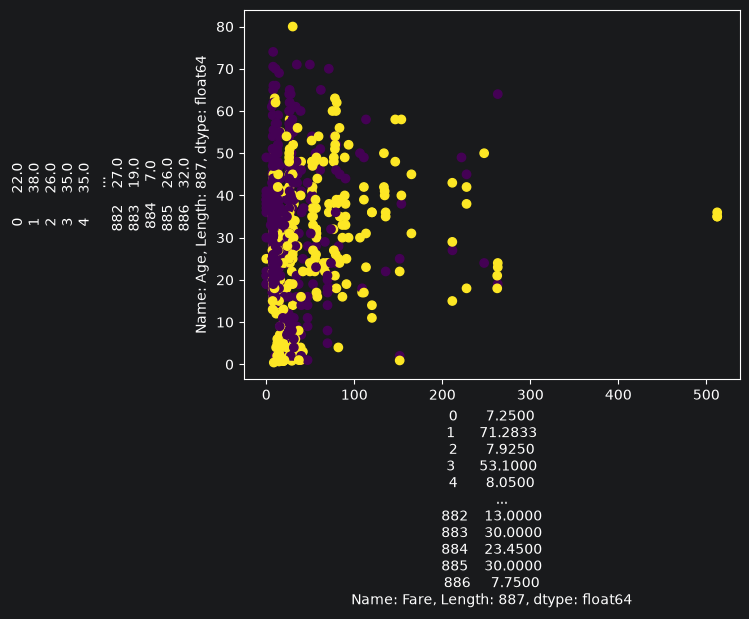

In [25]:
from pyexpat import features

# Classification Graphically

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from fontTools.merge import cmap

df = pd.read_csv("titanic.csv")

plt.xlabel(df['Fare'])
plt.ylabel(df['Age'])

plt.scatter(df["Fare"], df["Age"], c=df["Survived"], cmap='viridis')

plt.show()


In [26]:
# Linear Regression Model

# 1. Prepare Data with Pandas

df['Male'] = df['Sex'] == "male"

X = df[['Pclass', 'Male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values[:20]
Y = df['Survived'].values[:20]

print(X)
print(Y)

[[3 True 22.0 1 0 7.25]
 [1 False 38.0 1 0 71.2833]
 [3 False 26.0 0 0 7.925]
 [1 False 35.0 1 0 53.1]
 [3 True 35.0 0 0 8.05]
 [3 True 27.0 0 0 8.4583]
 [1 True 54.0 0 0 51.8625]
 [3 True 2.0 3 1 21.075]
 [3 False 27.0 0 2 11.1333]
 [2 False 14.0 1 0 30.0708]
 [3 False 4.0 1 1 16.7]
 [1 False 58.0 0 0 26.55]
 [3 True 20.0 0 0 8.05]
 [3 True 39.0 1 5 31.275]
 [3 False 14.0 0 0 7.8542]
 [2 False 55.0 0 0 16.0]
 [3 True 2.0 4 1 29.125]
 [2 True 23.0 0 0 13.0]
 [3 False 31.0 1 0 18.0]
 [3 False 22.0 0 0 7.225]]
[0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1]


[[ 0.01615934 -0.0154909 ]] [-0.51035265]


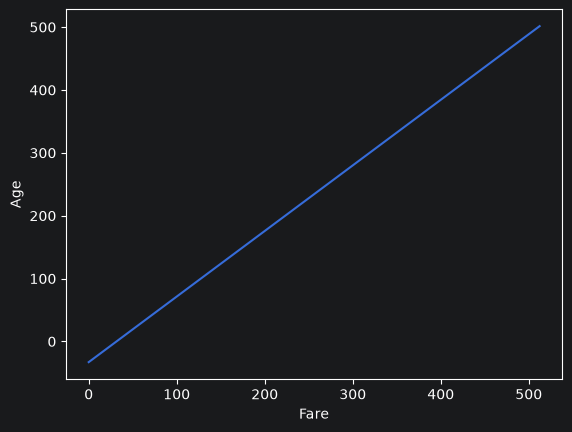

In [27]:
# Building a Logistic Regression Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

X = df[['Fare', 'Age']].values
y = df['Survived'].values

model.fit(X, y)

print(model.coef_, model.intercept_) # Coefficients x,y and intercept c. From ax+by+c = 0

plt.xlabel('Fare')
plt.ylabel('Age')

# plt.scatter(df['Fare'], df['Age'], c=df['Survived'])
# plt.plot((df['Fare']*model.coef_[0][1]), (df['Age']*model.coef_[0][0]))
# plt.show()

fare_vals = np.linspace(df['Fare'].min(), df['Fare'].max(), 100) #Return evenly spaced numbers / datapoints over a specified interval.
# print(fare_vals)
age_vals = -(0.0161594*fare_vals - 0.51037152) / -0.01549065 #Equivalent to y=-(ax-c)/-b
plt.plot(fare_vals, age_vals)
plt.show()


In [28]:
### Make Predictions with the Model

model = LogisticRegression()

X = df[['Pclass', 'Male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values
y = df['Survived'].values

model.fit(X, y)
print(model.predict([[3, True, 22.0, 1, 0, 7.25]])) # user-inputted data points
print(model.predict(X[:6])) # from first 6 rows of data array
print(y[:6]) # compare to first 6 values of target array
# Excellent it got all 6 correct!

[0]
[0 1 1 1 0 0]
[0 1 1 1 0 0]


In [29]:
### Score the Model

y_pred = model.predict(X)
print((y == y_pred).sum()) # only 714 out of 887 datapoints are correct predictions
print((y == y_pred).sum() / y.shape[0]*100) # compute accuracy score, we get it's 80.4%
print(model.score(X,y)) # use score(X,y) method to compute the accuracy score


714
80.49605411499437
0.8049605411499436


# BREAST CANCER DATASET

In [30]:
from sklearn.datasets import load_breast_cancer
cancer_data = load_breast_cancer()

print(cancer_data.keys())
print(cancer_data['DESCR'])

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 f

In [31]:
### Loading the Data into Pandas

print(cancer_data['data'].shape) # data entries = 569, features = 30

### now put the data into Pandas DataFrame to make more human-readable
### we will want column names which will be stored with 'feature_names' key

print(cancer_data['feature_names']) # print all feature names

df = pd.DataFrame(cancer_data['data'], columns=cancer_data['feature_names'])
print(df.head()) # print the DataFrame

## Now we put the target data as well in the Pandas DataFrame

print(cancer_data['target'])
print(cancer_data['target'].shape)

print(cancer_data['target_names']) # returns the target names used in this dataset ['malignant' 'benign']

df['target'] = cancer_data['target']

print(df.head()) # you will notice that now we have 31 columns

(569, 30)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0

In [32]:
### Now let's Build a Logistic Regression Model from the Breast Cancer Dataset

# 1. Build feature matrix X, and target array y

X = df[cancer_data.feature_names].values
y = df['target'].values

# 2. Let's create a Logistic Regression object

# model = LogisticRegression() # When we run this code we get a Convergence Warning. This means that the model needs more time to find the optimal solution.
# model.fit(X, y)

# One option is to increase the number of iterations. Which is why we decided to switch to a different solver, 'liblinear'.
model = LogisticRegression(solver='liblinear')
model.fit(X, y)

model.predict(X[:100])

# Then how much is the model accurate?
accuracy = model.score(X, y)
print("The model has: " + str(accuracy*100) + "% accuracy.")


The model has: 95.95782073813707% accuracy.


In [33]:
### PRACTICAL EXERCISE - MACHINE LEARNING - BOB THE BUILDER

"""
Task
You are given a feature matrix and a single datapoint to predict. Your job will be to build a Logistic Regression model with the feature matrix and make a prediction (1 or 0) of the single datapoint.

Input Format
First line: Number of data points in the feature matrix (n)
Next n lines: Values of the row in the feature matrix, separated by spaces
Next line: Target values separated by spaces
Final line: Values (separated by spaces) of a single datapoint without a target value

Output Format
Either 1 or 0

Sample Input
6
1 3
3 5
5 7
3 1
5 3
7 5
1 1 1 0 0 0
2 4

Sample Output
1
"""

# input number of data points in the feature matrix (n)
n = int(input())

# values of row in the feature matrix, separated by spaces
X = []
for i in range(n):
    X.append([float(x) for x in input().split()])

# target values separated by spaces
y = [int (x) for x in input().split()]

# values of a single datapoint separated by spaces
datapoint = [float(x) for x in input().split()]

print(X)
print(y)
print(datapoint)

model = LogisticRegression()
model.fit(X, y)

prediction = model.predict([datapoint])[0]
print(prediction)


[[1.0, 3.0], [3.0, 5.0], [5.0, 7.0], [3.0, 1.0], [5.0, 3.0], [7.0, 5.0]]
[1, 1, 1, 0, 0, 0]
[20.0, 3.0]
0


"\nWhy Predict 1?\n\nThe output is 1 because the Logistic Regression model identifies a clear linear pattern in the training data that separates the two classes, and the new datapoint (2, 4) falls squarely into the region associated with class 1.\n\nHere is the step-by-step breakdown of why this happens:\n\n1. Analyze the Training Data\nLet's look at the feature matrix and the corresponding target values:\nTarget 1: (1, 3), (3, 5), (5, 7)\nTarget 0: (3, 1), (5, 3), (7, 5)\n\nIf you look closely at the relationship between the two features (let's call them x1 and x2)\n-> For all Target 1 points, the second feature is strictly greater than the first features (x2 > x1). Specifically, x2 - x1 = 2.\n-> For all Target 0 points, the second feature is strictly less than the first feature (x2 < x1). Specifically, x2 - x1 = -2.\n\n2. How Logistic Regression Learns This\nLogistic Regression tries to find a linear decision boundary (a line) that best separates the classes. It learns weights (w1, w

Why Predict 1?

The output is 1 because the Logistic Regression model identifies a clear linear pattern in the training data that separates the two classes, and the new datapoint (2, 4) falls squarely into the region associated with class 1.

Here is the step-by-step breakdown of why this happens:

1. Analyze the Training Data
Let's look at the feature matrix and the corresponding target values:
- Target 1: (1, 3), (3, 5), (5, 7)
- Target 0: (3, 1), (5, 3), (7, 5)

If you look closely at the relationship between the two features (let's call them x1 and x2)
- For all Target 1 points, the second feature is strictly greater than the first features (x2 > x1). Specifically, x2 - x1 = 2.
- For all Target 0 points, the second feature is strictly less than the first feature (x2 < x1). Specifically, x2 - x1 = -2.

2. How Logistic Regression Learns This
Logistic Regression tries to find a linear decision boundary (a line) that best separates the classes. It learns weights (w1, w2) and an intercept (b) to calculate a score z = w1x1 + w2x2 + b.

If we actually train a standard Logistic Regression model on this data, it learns approximately:
- w1 ≈ -0.88
- w2 ≈ 0.88
- b ≈ 0

This means the decision boundary is roughly -0.88x1 + 0.88x2 = 0, which simplifies to x2 = x1.
- If x2 > x1, the score z is positive, pushing the probability toward 1.
- If x2 < x1, the score z is negative, pushing the probability toward 0.

3. Evaluate the New Datapoint
The final line of the input is the datapoint to predict: 2 4 (x1 = 2, x2 = 4).

Let's plug this into the learned model:

- z=(−0.88×2)+(0.88×4)+0
- z=−1.76+3.52=1.76

The model then passes this score through the sigmoid function to get a probability:

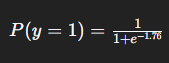 ≈0.853 (or 85.3%)

Since the probability (85.3%) is greater than the default threshold of 50% (0.5), the model confidently predicts the class as 1.

Intuitively, because 4 > 2, the point (2, 4) perfectly matches the pattern established by the Target 1 examples in the training data.